# Laptop Price Predictor — Part 2 of 4
### Checking missing data · Missing Data Treatment · Duplicate Checking · Duplicate Removing

| Part | Notebook | Assignment steps |
|---|---|---|
| 1 | `Part1_Data_Loading_and_Feature_Extraction.ipynb` | 1 Import Library · 2 Data Loading · 3 Feature Extraction · 4 Data Info |
| **2** | **`Part2_Missing_Data_and_Duplicates.ipynb`** ← you are here | **5 Checking missing data · 6 Missing Data Treatment · 7 Duplicate Checking · 8 Duplicate Removing** |
| 3 | `Part3_Visualization_and_Feature_Engineering.ipynb` | 9 Data Visualization · 10 Correlation with target · 11 Features and target separation · 12 Feature Selection · 13 Feature Scaling · 14 PCA · 15 Encoding |
| 4 | `Part4_Model_Training_and_Cross_Validation.ipynb` | 16 Train Test Split · 17 Model Preparation · 18 Model Accuracy · 19 Cross_val function · 20 cross_val Accuracy |

**Input:** `laptop_part1_features.csv` (from Part 1) → **Output:** `laptop_part2_clean.csv`

**Running in Google Colab:** *Runtime → Run all*. Upload `laptop_part1_features.csv` when asked.

## Setup: libraries and the Part 1 output

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

try:
    from google.colab import files  # this import only works inside Google Colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)


def find_file(name):
    """Find a data file next to the notebook, in a data/ folder or in Colab's /content.
    In Colab, if the file is missing, ask for an upload."""
    for folder in [".", "data", "/content", "/content/data"]:
        path = os.path.join(folder, name)
        if os.path.exists(path):
            return path
    if IN_COLAB:
        print(f"'{name}' was not found - please upload it.")
        uploaded = files.upload()
        return next(iter(uploaded))  # Colab saves the upload in /content
    raise FileNotFoundError(f"Put '{name}' next to this notebook (or in a data/ folder) and run again.")


def save_output(frame, name):
    """Save a CSV for the next part. In Colab the file is also downloaded so you can upload it there."""
    folder = "data" if os.path.isdir("data") else "."
    path = os.path.join(folder, name)
    frame.to_csv(path, index=False)
    print(f"Saved {path}  ->  {frame.shape[0]} rows x {frame.shape[1]} columns")
    if IN_COLAB:
        files.download(path)

# One quiet chart style for the whole project: recessive grid, data in color, text in ink.
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
BLUE, BLUE_LIGHT, ORANGE, RED = "#2a78d6", "#b7d3f6", "#eb6834", "#e34948"
INK, INK_2, GRID, SURFACE = "#0b0b0b", "#52514e", "#e4e3de", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.grid": True, "axes.axisbelow": True,
    "grid.color": GRID, "grid.linewidth": 1,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.labelcolor": INK_2, "xtick.color": INK_2, "ytick.color": INK_2, "text.color": INK,
    "axes.prop_cycle": plt.cycler(color=SERIES), "font.size": 10, "figure.dpi": 100,
    "lines.linewidth": 2,
})
thousands = mticker.StrMethodFormatter("{x:,.0f}")


df = pd.read_csv(find_file("laptop_part1_features.csv"))
print("Shape:", df.shape)
df.head()

Shape: (845, 20)


,brand,model,processor_brand,processor_name,ram_gb,ram_type,ssd,hdd,os,os_bit,graphic_card_gb,laptop_type,warranty,touchscreen,msoffice,price,processor_gen,cpu_family,display_inch,total_storage_gb
0,ASUS,celeron,Intel,5,4.0,Cooling,0,1024,Windows,64,0,Casual,1,No,No,23990.0,NaN,NaN,15.6,1024
1,ASUS,vivobook,Intel,5,4.0,DDR3,512,0,Windows,64,0,Casual,1,No,No,37990.0,10.0,NaN,15.6,512
2,ASUS,vivobook,Intel,A6-9225 Processor,4.0,DDR3,0,1024,Windows,64,0,Casual,1,No,No,NaN,10.0,Entry level,14.1,1024
3,HP,core,Intel,APU Dual,4.0,DDR3,512,0,Windows,64,0,ThinNlight,1,No,Yes,54990.0,11.0,Entry level,15.6,512
4,HP,core,Intel,APU Dual,4.0,DDR3,512,0,Windows,64,0,ThinNlight,0,No,No,54990.0,11.0,Entry level,15.6,512


## Step 5: Checking missing data

### 5.1 Missing values pandas can see (`NaN`)

In [2]:
def missing_table(frame):
    counts = frame.isna().sum()
    table = pd.DataFrame({"missing": counts, "percent": (counts / len(frame) * 100).round(1)})
    return table[table["missing"] > 0].sort_values("missing", ascending=False)


missing_table(df)

,missing,percent
processor_gen,304,36.0
cpu_family,18,2.1
price,3,0.4
display_inch,3,0.4


### 5.2 Hidden missing values

Some gaps are written as text (`"Missing"`) or as impossible values, so `isna()` cannot see them.
Each rule below finds one kind of hidden missing value:

In [3]:
VALID_RAM_GB = [4, 8, 16, 32]                                   # RAM is sold in these sizes
VALID_CPU_BRANDS = ["Intel", "AMD", "Apple", "MediaTek", "Qualcomm"]
no_storage = df["ssd"].eq(0) & df["hdd"].eq(0)                  # a laptop always has some storage

hidden_rules = [
    # (column,          what is wrong,                               rows affected)
    ("os",              'text "Missing"',                            df["os"].eq("Missing")),
    ("display_inch",    "screen size of 0 inches",                   df["display_inch"].eq(0)),
    ("ram_gb",          "RAM size that does not exist (15.6, 5)",    ~df["ram_gb"].isin(VALID_RAM_GB)),
    ("processor_brand", "not a CPU maker (NVIDIA, M.2, 512, ...)",   ~df["processor_brand"].isin(VALID_CPU_BRANDS)),
    ("ram_type",        "not a RAM type (GTX, LED, Cooling, ...)",   ~df["ram_type"].str.contains("DDR|Unified", na=False)),
    ("ssd",             "no SSD and no HDD (0 GB storage)",          no_storage),
    ("total_storage_gb", "0 GB storage",                             no_storage),
]

pd.DataFrame(
    [(col, rule, int(mask.sum()), df.loc[mask, col].unique()[:6].tolist()) for col, rule, mask in hidden_rules],
    columns=["column", "hidden missing value", "rows", "values found"],
)

,column,hidden missing value,rows,values found
0,os,"text ""Missing""",64,[Missing]
1,display_inch,screen size of 0 inches,58,[0.0]
2,ram_gb,"RAM size that does not exist (15.6, 5)",7,"[5.0, 15.6]"
3,processor_brand,"not a CPU maker (NVIDIA, M.2, 512, ...)",14,"[NVIDIA, Pre-installed, First, 512, M.2]"
4,ram_type,"not a RAM type (GTX, LED, Cooling, ...)",13,"[Cooling, Full, GTX, i5, LED, Master]"
5,ssd,no SSD and no HDD (0 GB storage),60,[0]
6,total_storage_gb,0 GB storage,60,[0]


Replace every hidden missing value with a real `NaN`, so all gaps are counted and treated the same way:

In [4]:
for col, rule, mask in hidden_rules:
    df[col] = df[col].mask(mask)        # mask() puts NaN where the rule is True

missing_before = missing_table(df)
missing_before

,missing,percent
processor_gen,304,36.0
os,64,7.6
display_inch,61,7.2
ssd,60,7.1
total_storage_gb,60,7.1
cpu_family,18,2.1
processor_brand,14,1.7
ram_type,13,1.5
ram_gb,7,0.8
price,3,0.4


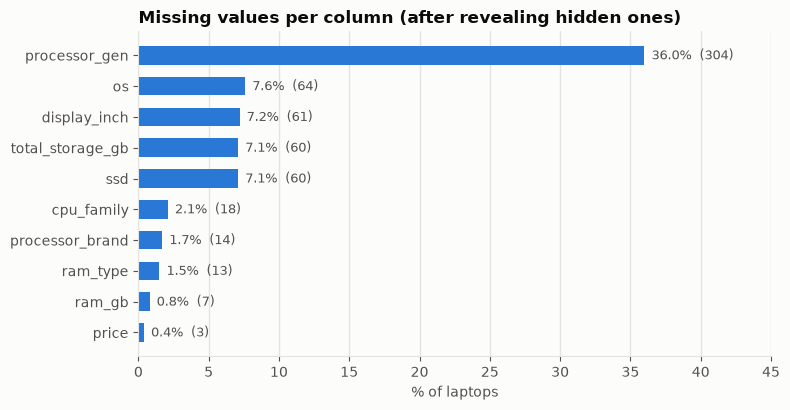

In [5]:
fig, ax = plt.subplots(figsize=(8, 4.2))
plot_data = missing_before.sort_values("percent")
ax.barh(plot_data.index, plot_data["percent"], color=BLUE, height=0.6)
for y, (pct, n) in enumerate(zip(plot_data["percent"], plot_data["missing"])):
    ax.text(pct + 0.5, y, f"{pct:.1f}%  ({n})", va="center", color=INK_2, fontsize=9)
ax.set_title("Missing values per column (after revealing hidden ones)")
ax.set_xlabel("% of laptops")
ax.set_xlim(0, plot_data["percent"].max() * 1.25)
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

After the hidden values are revealed, **10 columns have gaps**. `processor_gen` is the biggest problem
(36% missing); every other column is under 8%.

## Step 6: Missing Data Treatment

| Column | Treatment | Why |
|---|---|---|
| `price` | **Drop the rows** | It is the target. Filling it in would invent the answer the model must learn. |
| `processor_gen`, `display_inch`, `ssd` | **Median** | Numeric; the median is not pulled by very cheap or very expensive laptops. |
| `total_storage_gb` | **Recompute** as `ssd + hdd` | Keeps it consistent with the imputed `ssd`. |
| `ram_gb` | **Mode** (most common size) | RAM comes in fixed sizes; a median could give a size that does not exist. |
| `os`, `processor_brand`, `ram_type`, `cpu_family` | **Mode** (most common value) | Categorical columns have no average. |

### 6.1 Drop rows with no price (target)

In [6]:
before = len(df)
df = df.dropna(subset=["price"]).reset_index(drop=True)
print(f"Rows without a price removed: {before - len(df)}  ({before} -> {len(df)} rows)")

Rows without a price removed: 3  (845 -> 842 rows)


### 6.2 Numeric columns → median

In [7]:
for col in ["processor_gen", "display_inch", "ssd"]:
    n_missing = int(df[col].isna().sum())
    median = df[col].median()
    df[col] = df[col].fillna(median)
    print(f"{col:<15} {n_missing:>4} filled with median = {median}")

df["total_storage_gb"] = df["ssd"] + df["hdd"]
print("total_storage_gb recomputed as ssd + hdd")

processor_gen    303 filled with median = 11.0
display_inch      61 filled with median = 15.0
ssd               60 filled with median = 512.0
total_storage_gb recomputed as ssd + hdd


### 6.3 RAM and categorical columns → mode

In [8]:
for col in ["ram_gb", "os", "processor_brand", "ram_type", "cpu_family"]:
    n_missing = int(df[col].isna().sum())
    mode = df[col].mode()[0]
    df[col] = df[col].fillna(mode)
    print(f"{col:<16} {n_missing:>4} filled with mode = {mode}")

ram_gb              7 filled with mode = 8.0
os                 64 filled with mode = Windows
processor_brand    14 filled with mode = Intel
ram_type           13 filled with mode = DDR4
cpu_family         18 filled with mode = Intel Core i5


### 6.4 Tidy the data types and verify

In [9]:
for col in ["ram_gb", "ssd", "total_storage_gb", "processor_gen"]:
    df[col] = df[col].astype(int)        # these are whole numbers again after imputation

print("Missing values left:", int(df.isna().sum().sum()))
assert df.isna().sum().sum() == 0, "There are still missing values"
df.isna().sum().to_frame("missing").T

Missing values left: 0


,brand,model,processor_brand,processor_name,ram_gb,ram_type,ssd,hdd,os,os_bit,graphic_card_gb,laptop_type,warranty,touchscreen,msoffice,price,processor_gen,cpu_family,display_inch,total_storage_gb
missing,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


`processor_name` keeps its original text (including a few non-processor values such as `GB SSD`). The clean
version of that information is `cpu_family`; Part 3 decides which of the two the model uses.

## Step 7: Duplicate Checking

A duplicate row is the same laptop listed twice. If it stays, the model can see the same laptop in both the
training and the test set, which makes the accuracy look better than it really is.

In [10]:
n_dup = int(df.duplicated().sum())
print("Duplicate rows (exact copies of an earlier row):", n_dup)

Duplicate rows (exact copies of an earlier row): 10


In [11]:
# Every copy, sorted so that duplicates sit next to each other
dup_rows = df[df.duplicated(keep=False)]
dup_rows.sort_values(list(df.columns))

,brand,model,processor_brand,processor_name,ram_gb,ram_type,ssd,hdd,os,os_bit,graphic_card_gb,laptop_type,warranty,touchscreen,msoffice,price,processor_gen,cpu_family,display_inch,total_storage_gb
215,APPLE,2021,Apple,Core i5,8,DDR4,1024,0,Mac,64,0,Casual,1,No,No,225990.0,11,Intel Core i5,14.2,1024
293,APPLE,2021,Apple,Core i5,8,DDR4,1024,0,Mac,64,0,Casual,1,No,No,225990.0,11,Intel Core i5,14.2,1024
284,APPLE,macbook,Intel,Core i5,8,DDR4,1024,0,Mac,64,0,Casual,1,No,No,179990.0,10,Intel Core i5,13.0,1024
333,APPLE,macbook,Intel,Core i5,8,DDR4,1024,0,Mac,64,0,Casual,1,No,No,179990.0,10,Intel Core i5,13.0,1024
308,ASUS,pentium,Intel,Core i5,8,DDR4,0,1024,Windows,64,0,Casual,1,No,No,25990.0,11,Intel Core i5,15.6,1024
310,ASUS,pentium,Intel,Core i5,8,DDR4,0,1024,Windows,64,0,Casual,1,No,No,25990.0,11,Intel Core i5,15.6,1024
51,ASUS,vivobook,AMD,Core i3,4,DDR4,256,1024,Windows,64,0,Casual,1,No,No,54990.0,11,Intel Core i3,15.6,1280
82,ASUS,vivobook,AMD,Core i3,4,DDR4,256,1024,Windows,64,0,Casual,1,No,No,54990.0,11,Intel Core i3,15.6,1280
237,ASUS,vivobook,AMD,Core i5,8,DDR4,512,0,Windows,64,0,Casual,1,No,No,58990.0,11,Intel Core i5,14.0,512
386,ASUS,vivobook,AMD,Core i5,8,DDR4,512,0,Windows,64,0,Casual,1,No,No,58990.0,11,Intel Core i5,14.0,512


## Step 8: Duplicate Removing

In [12]:
before = len(df)
df = df.drop_duplicates(keep="first").reset_index(drop=True)
print(f"Duplicate rows removed: {before - len(df)}  ({before} -> {len(df)} rows)")

assert df.duplicated().sum() == 0, "Duplicates are still present"
print("Duplicates left:", int(df.duplicated().sum()))

Duplicate rows removed: 10  (842 -> 832 rows)
Duplicates left: 0


### Final check of the clean data

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 832 entries, 0 to 831
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   brand             832 non-null    str    
 1   model             832 non-null    str    
 2   processor_brand   832 non-null    str    
 3   processor_name    832 non-null    str    
 4   ram_gb            832 non-null    int64  
 5   ram_type          832 non-null    str    
 6   ssd               832 non-null    int64  
 7   hdd               832 non-null    int64  
 8   os                832 non-null    str    
 9   os_bit            832 non-null    int64  
 10  graphic_card_gb   832 non-null    int64  
 11  laptop_type       832 non-null    str    
 12  warranty          832 non-null    int64  
 13  touchscreen       832 non-null    str    
 14  msoffice          832 non-null    str    
 15  price             832 non-null    float64
 16  processor_gen     832 non-null    int64  
 17  cpu_fami

In [14]:
save_output(df, "laptop_part2_clean.csv")

Saved data/laptop_part2_clean.csv  ->  832 rows x 20 columns


**Next:** open `Part3_Visualization_and_Feature_Engineering.ipynb`.